# Simple Linear Regression – Marketing ROI Analysis

## Objective

The objective of this project is to determine which marketing channel has the strongest influence on Sales and to build a Simple Linear Regression model using Statsmodels to quantify that relationship.

The analysis follows a structured workflow including data exploration, data cleaning, correlation analysis, regression modeling, assumption testing, and business recommendations.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

## Importing Libraries

The required libraries are imported for data manipulation, visualization, and regression analysis.

In [40]:
df = pd.read_csv("marketing_and_sales_data_evaluate_lr.csv")
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


## Dataset Preview

The first five rows are displayed to understand the structure of the dataset.

In [41]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


## Dataset Exploration

The dataset contains information on TV, Radio, Social Media advertising expenditures and Sales.

The purpose of this step is to understand the dataset structure, identify variable types, and obtain summary statistics.

In [42]:
df.isnull().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

## Missing Value Assessment

Missing values must be addressed before model building because regression algorithms cannot process incomplete observations.

In [43]:
df_clean = df.dropna()
df_clean.shape

(4546, 4)

In [44]:
df_clean.isnull().sum()

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

## Data Cleaning

Rows containing missing values were removed using dropna().

The resulting dataset contains only complete observations suitable for regression analysis.

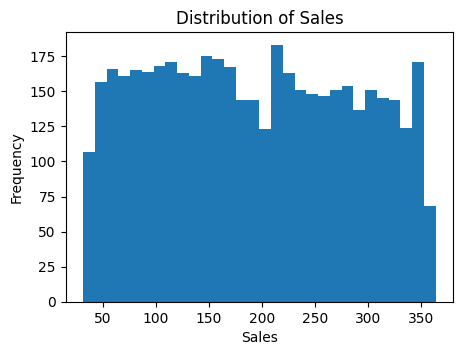

In [56]:
plt.figure(figsize=(5,3.5))

plt.hist(df_clean["Sales"], bins=30)

plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Sales")

plt.savefig("images/sales_distribution.png", bbox_inches="tight")
plt.show()

## Distribution of Sales

The histogram provides an overview of the distribution of the target variable (Sales).

Understanding the distribution helps identify unusual patterns and supports later model interpretation.

In [46]:
correlation_matrix = df_clean.corr()

correlation_matrix

,TV,Radio,Social_Media,Sales
TV,1.000000,0.869158,0.527687,0.999497
Radio,0.869158,1.000000,0.606338,0.868638
Social_Media,0.527687,0.606338,1.000000,0.527446
Sales,0.999497,0.868638,0.527446,1.000000


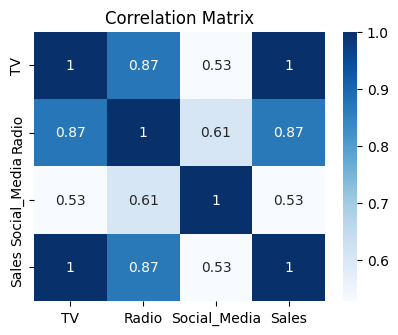

In [57]:
plt.figure(figsize=(4.7,3.5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues"
)
plt.title("Correlation Matrix")

plt.savefig("images/correlation_heatmap.png", bbox_inches="tight")
plt.show()

## Correlation Analysis

Correlation analysis is used to identify the marketing variable most strongly associated with Sales.

The variable with the highest correlation will be selected as the predictor variable for the Simple Linear Regression model.

In [48]:
correlation_matrix["Sales"]

TV              0.999497
Radio           0.868638
Social_Media    0.527446
Sales           1.000000
Name: Sales, dtype: float64

## Variable Selection

TV advertising has the strongest correlation with Sales (0.9995).

Therefore:

- Independent Variable (X): TV
- Dependent Variable (y): Sales

TV is selected as the predictor variable for the regression model.

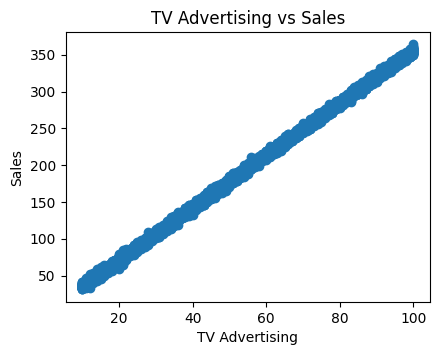

In [58]:
plt.figure(figsize=(4.7,3.5))
plt.scatter(df_clean["TV"], df_clean["Sales"])

plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("TV Advertising vs Sales")

plt.savefig("images/tv_vs_sales.png", bbox_inches="tight")
plt.show()

## Relationship Between TV Advertising and Sales

The scatter plot shows a strong positive linear relationship between TV advertising expenditure and Sales.

This supports the use of Simple Linear Regression.

In [50]:
X = df_clean["TV"]

y = df_clean["Sales"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Fri, 19 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:17:28   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

## OLS Regression Model

An Ordinary Least Squares (OLS) regression model was built using TV advertising as the predictor variable.

## Model Interpretation

### R-squared

R² = 0.999

This means approximately 99.9% of the variation in Sales is explained by TV advertising.

### Coefficient

TV Coefficient = 3.5615

For every one-unit increase in TV advertising expenditure, Sales increase by approximately 3.56 units.

### P-value

P-value = 0.000

Since the p-value is less than 0.05, TV advertising is a statistically significant predictor of Sales.

In [51]:
predictions = model.predict(X)

residuals = model.resid

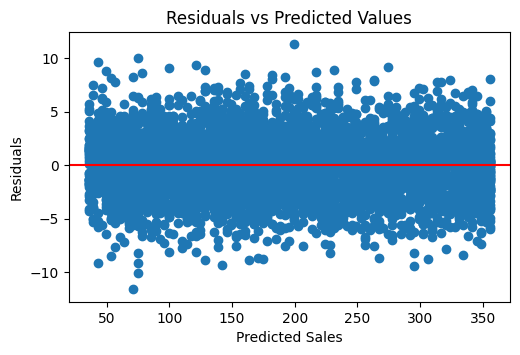

In [59]:
plt.figure(figsize=(5.7,3.5))
plt.scatter(predictions, residuals)
plt.axhline(y=0, color='red')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.savefig("images/residuals_vs_fitted.png", bbox_inches="tight")
plt.show()

## Linearity and Homoscedasticity

The residuals are randomly scattered around the zero line.

This indicates that:

- The linearity assumption is satisfied.
- The homoscedasticity assumption is satisfied.

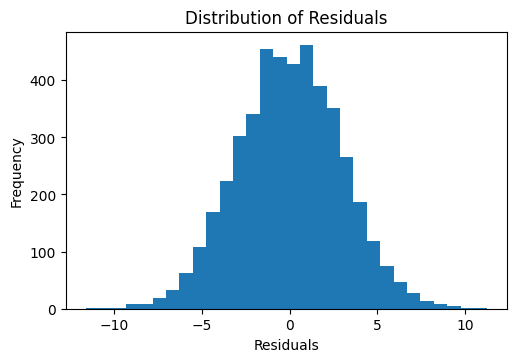

In [60]:
plt.figure(figsize=(5.7,3.6))
plt.hist(residuals, bins=30)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.savefig("images/residual_histogram.png", bbox_inches="tight")
plt.show()

<Figure size 570x360 with 0 Axes>

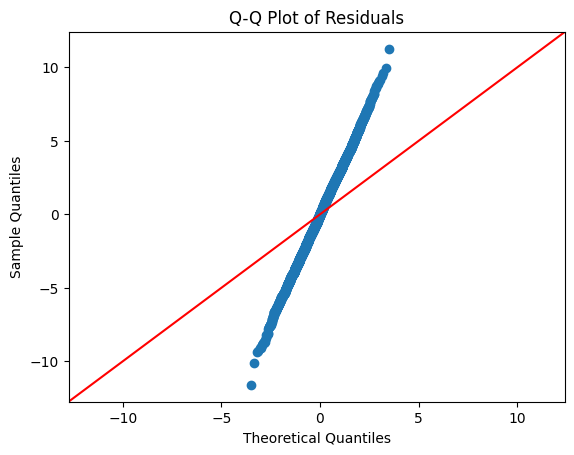

In [61]:
plt.figure(figsize=(5.7,3.6))
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot of Residuals")

plt.savefig("images/qq_plot.png", bbox_inches="tight")
plt.show()

## Normality Assessment

The residual histogram and Q-Q plot indicate that residuals are approximately normally distributed.

Therefore, the normality assumption is satisfied.

In [55]:
model.params

const   -0.132493
TV       3.561514
dtype: float64

## Final Regression Equation

Sales = -0.132493 + 3.561514(TV)

Interpretation:

For every additional unit spent on TV advertising, Sales increase by approximately 3.56 units.

## Marketing ROI Recommendation

Based on the correlation analysis and OLS regression results, TV advertising is the strongest predictor of Sales.

Key findings:

- Highest correlation with Sales (0.9995)
- R² = 0.999
- Statistically significant p-value (0.000)

Recommendation:

The company should prioritize TV advertising when allocating marketing budgets because it demonstrates the strongest impact on Sales and provides the highest expected return on investment (ROI).